# Who Can Still Afford Berlin?
## Housing Pressure Across Berlin Districts

**Project:** Berlin Housing Affordability Analysis  
**Tools:** Python (Pandas, Matplotlib, Seaborn) + Tableau  
**Date:** April 2026

---

### Project Overview

This project investigates housing affordability across Berlin's 12 districts (Bezirke) by combining rental listing data with income statistics and social indicators. The central question: **Which districts are still affordable, and who is being priced out?**

### Datasets Used

| Dataset | Source | Rows | Description |
|---------|--------|------|-------------|
| `berlin_core_clean.csv` | ImmoScout24 (scraped) | 10,309 | Individual rental listings with rent, size, rooms, amenities |
| `social_atlas_clean.csv` | Berlin Social Atlas 2022 | 12 | Social status indices (GESIx, ESIx) per district |
| `rent_clean.csv` | ImmobilienScout24 | 80 | Rent & purchase prices per borough |
| `berlin_income_by_district.csv` | Statistik Berlin-Brandenburg | 12 | Average household income, unemployment, demographics |
| `affordability_ranking.csv` | Derived | 12 | Combined affordability scores |

### Why We Added Income Data

The original dataset had excellent rental price data but **no income information**. Since affordability is fundamentally about the relationship between rent and income (the "rent burden"), we created `berlin_income_by_district.csv` using publicly available statistics from Berlin-Brandenburg's statistical office. This allows us to calculate rent-to-income ratios and answer the core question of who can still afford to live in each district.


## 1. Setup & Data Loading


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw"
processed_path = project_root / "data" / "processed"
figures_path = project_root / "figures"
reports_path = project_root / "reports"

In [10]:
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 7)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
berlin_core_clean = pd.read_csv(processed_path / "berlin_core_clean.csv")
social_atlas_clean = pd.read_csv(processed_path / "social_atlas_clean.csv")
housing_bezirk = pd.read_csv(processed_path / "housing_bezirk_summary.csv")
housing_social = pd.read_csv(processed_path / "housing_social_summary.csv")
neighborhood_rent = pd.read_csv(processed_path / "neighborhood_rent_summary.csv")
district_part_rent = pd.read_csv(processed_path / "district_part_rent_summary.csv")
affordability_ranking = pd.read_csv(processed_path / "affordability_ranking.csv")
berlin_affordability_master = pd.read_csv(processed_path / "berlin_affordability_master.csv")
berlin_housing_detailed_tableau = pd.read_csv(processed_path / "berlin_housing_detailed_tableau.csv")
berlin_income = pd.read_csv(raw_path / "berlin_income_by_district.csv")

In [12]:
(
    berlin_core_clean.shape,
    social_atlas_clean.shape,
    housing_bezirk.shape,
    housing_social.shape,
    neighborhood_rent.shape,
    district_part_rent.shape,
    affordability_ranking.shape,
    berlin_affordability_master.shape,
    berlin_housing_detailed_tableau.shape,
    berlin_income.shape
)

((10309, 28),
 (12, 12),
 (12, 6),
 (12, 18),
 (65, 3),
 (23, 2),
 (12, 12),
 (12, 28),
 (10309, 36),
 (12, 6))

In [14]:
housing = berlin_core_clean.copy()
social = social_atlas_clean.copy()
income = berlin_income.copy()

## 2. Data Exploration


In [15]:
# Preview the main housing dataset
housing.head()


,regio1,regio2,regio3,baseRent,totalRent,livingSpace,noRooms,floor,numberOfFloors,yearConstructed,...,serviceCharge,heatingType,newlyConst,picturecount,pricetrend,date,rent_per_sqm,neighborhood,district_part,bezirk
0,Berlin,Berlin,Staaken_Spandau,820.00,1140.00,77.00,3.0,0.0,3.0,NaN,...,320.00,central_heating,False,10,4.99,Feb20,10.649351,Staaken,Spandau,Spandau
1,Berlin,Berlin,Weißensee_Weißensee,808.00,955.00,62.63,2.0,0.0,3.0,1918.0,...,79.00,central_heating,False,17,7.35,Oct19,12.901166,Weißensee,Weißensee,Pankow
2,Berlin,Berlin,Mitte_Mitte,1150.00,1300.00,46.40,2.0,3.0,5.0,2019.0,...,150.00,floor_heating,True,15,6.60,Oct19,24.784483,Mitte,Mitte,Mitte
3,Berlin,Berlin,Kreuzberg_Kreuzberg,1200.00,1428.78,67.00,2.5,6.0,7.0,2017.0,...,228.78,floor_heating,False,2,8.63,Oct19,17.910448,Kreuzberg,Kreuzberg,Friedrichshain-Kreuzberg
4,Berlin,Berlin,Tiergarten_Tiergarten,1338.43,1559.05,73.54,2.0,0.0,6.0,2019.0,...,147.08,district_heating,True,9,7.56,Feb20,18.200027,Tiergarten,Tiergarten,Mitte


In [16]:
# Data types and missing values
print("=== Data Types ===")
print(housing.dtypes)
print("\n=== Missing Values (%) ===")
missing = (housing.isnull().sum() / len(housing) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))


=== Data Types ===
regio1              object
regio2              object
regio3              object
baseRent           float64
totalRent          float64
livingSpace        float64
noRooms            float64
floor              float64
numberOfFloors     float64
yearConstructed    float64
condition           object
interiorQual        object
lift                  bool
balcony               bool
hasKitchen            bool
cellar                bool
garden                bool
typeOfFlat          object
serviceCharge      float64
heatingType         object
newlyConst            bool
picturecount         int64
pricetrend         float64
date                object
rent_per_sqm       float64
neighborhood        object
district_part       object
bezirk              object
dtype: object

=== Missing Values (%) ===
interiorQual       40.8
numberOfFloors     29.9
condition          22.0
heatingType        14.2
yearConstructed    13.1
floor              10.6
typeOfFlat          7.7
totalRent      

In [17]:
# Quick stats on rent per sqm
print("=== Rent per sqm Statistics ===")
print(housing['rent_per_sqm'].describe().round(2))
print(f"\nDate range: {housing['date'].unique()}")
print(f"Districts: {housing['bezirk'].nunique()} unique bezirke")


=== Rent per sqm Statistics ===
count    10309.00
mean        14.06
std          5.10
min          5.10
25%         10.23
50%         13.17
75%         17.00
max         40.00
Name: rent_per_sqm, dtype: float64

Date range: ['Feb20' 'Oct19' 'May19' 'Sep18']
Districts: 12 unique bezirke


In [18]:
# Preview income dataset
income


,district_name,avg_monthly_income_eur,median_monthly_income_eur,unemployment_rate_pct,population,transfer_income_share_pct
0,Mitte,1850,1650,12.8,384000,22.5
1,Friedrichshain-Kreuzberg,1900,1750,9.2,289000,16.8
2,Pankow,2200,2050,6.5,413000,9.5
3,Charlottenburg-Wilmersdorf,2400,2200,7.8,342000,11.2
4,Spandau,1700,1550,11.5,245000,18.5
5,Steglitz-Zehlendorf,2600,2400,5.2,310000,7.0
6,Tempelhof-Schöneberg,2100,1950,8.3,351000,13.5
7,Neukölln,1650,1500,14.1,329000,24.0
8,Treptow-Köpenick,2050,1900,7.0,274000,10.5
9,Marzahn-Hellersdorf,1750,1600,10.8,269000,17.0


## 3. Data Cleaning

Key cleaning steps:
- Convert boolean columns from strings to actual booleans
- Ensure numeric columns are properly typed
- Remove outliers in rent_per_sqm (keep 5-40 EUR range)
- Standardize date format


In [19]:
# Fix boolean columns (stored as strings)
bool_cols = ['lift', 'balcony', 'hasKitchen', 'cellar', 'garden', 'newlyConst']
for col in bool_cols:
    if housing[col].dtype == object:  # Only convert if stored as strings
        housing[col] = housing[col].map({'True': True, 'False': False})

# Convert numeric columns
numeric_cols = ['baseRent', 'totalRent', 'livingSpace', 'noRooms', 'floor', 
                'numberOfFloors', 'yearConstructed', 'serviceCharge', 'rent_per_sqm']
for col in numeric_cols:
    housing[col] = pd.to_numeric(housing[col], errors='coerce')

# Remove outliers
before = len(housing)
housing = housing[(housing['rent_per_sqm'] >= 5) & (housing['rent_per_sqm'] <= 40)]
print(f"Removed {before - len(housing)} outlier rows (rent_per_sqm outside 5-40 EUR)")
print(f"Clean dataset: {len(housing):,} rows")

# Map dates to proper format
date_map = {'Sep18': '2018-09', 'May19': '2019-05', 'Oct19': '2019-10', 'Feb20': '2020-02'}
housing['date_clean'] = housing['date'].map(date_map)
print(f"\nDate distribution:")
print(housing['date'].value_counts())



Removed 0 outlier rows (rent_per_sqm outside 5-40 EUR)
Clean dataset: 10,309 rows

Date distribution:
date
May19    2847
Oct19    2741
Feb20    2736
Sep18    1985
Name: count, dtype: int64


## 4. Data Merging & Affordability Calculation

We merge housing data with income and social indicators at the district level to calculate **rent burden** (rent as a percentage of income).

The internationally recognized threshold is **30%** — spending more than 30% of income on rent is considered "housing stress".


In [20]:
# Aggregate housing data by district
district_housing = housing.groupby('bezirk').agg(
    avg_rent_sqm=('rent_per_sqm', 'mean'),
    median_rent_sqm=('rent_per_sqm', 'median'),
    avg_base_rent=('baseRent', 'mean'),
    avg_living_space=('livingSpace', 'mean'),
    listing_count=('rent_per_sqm', 'count'),
    avg_total_rent=('totalRent', 'mean')
).reset_index()

print("District-level housing summary:")
district_housing.round(2)


District-level housing summary:


,bezirk,avg_rent_sqm,median_rent_sqm,avg_base_rent,avg_living_space,listing_count,avg_total_rent
0,Charlottenburg-Wilmersdorf,16.12,15.24,1676.02,104.36,1250,1952.25
1,Friedrichshain-Kreuzberg,17.08,16.16,1315.69,79.14,874,1510.22
2,Lichtenberg,11.38,10.99,767.17,68.19,555,937.85
3,Marzahn-Hellersdorf,9.04,8.88,584.64,65.14,591,760.18
4,Mitte,17.54,17.09,1523.29,87.71,1894,1818.15
5,Neukölln,13.26,13.21,950.61,72.49,513,1171.69
6,Pankow,14.36,13.42,1191.62,82.64,1142,1371.99
7,Reinickendorf,11.05,10.66,816.50,74.56,517,1019.90
8,Spandau,9.77,9.36,702.40,72.58,612,884.30
9,Steglitz-Zehlendorf,12.88,12.07,1196.86,91.54,645,1425.86


In [21]:
# Merge all datasets
master = district_housing.merge(income, left_on='bezirk', right_on='district_name', how='left')
master = master.merge(social, on='district_name', how='left')

# Calculate affordability metrics
master['avg_monthly_rent'] = master['avg_base_rent']
master['rent_burden_pct'] = (master['avg_monthly_rent'] / master['avg_monthly_income_eur']) * 100

# Rent burden for a typical 60 sqm apartment using median values
master['median_rent_burden_pct'] = (master['median_rent_sqm'] * 60 / master['median_monthly_income_eur']) * 100

# Classify affordability
def classify_affordability(burden):
    if burden < 25: return 'Affordable'
    elif burden < 35: return 'Moderate'
    elif burden < 50: return 'Stressed'
    else: return 'Severely Burdened'

master['affordability_class'] = master['rent_burden_pct'].apply(classify_affordability)

# Display results
print("=== AFFORDABILITY ANALYSIS BY DISTRICT ===\n")
result = master[['district_name', 'avg_rent_sqm', 'avg_monthly_income_eur', 
                 'avg_monthly_rent', 'rent_burden_pct', 'affordability_class']]
result = result.sort_values('rent_burden_pct', ascending=False)
result.columns = ['District', 'Avg Rent/sqm', 'Avg Income', 'Avg Rent', 'Rent Burden %', 'Class']
print(result.to_string(index=False))


=== AFFORDABILITY ANALYSIS BY DISTRICT ===

                  District  Avg Rent/sqm  Avg Income    Avg Rent  Rent Burden %             Class
                     Mitte     17.539296        1850 1523.292476      82.340134 Severely Burdened
Charlottenburg-Wilmersdorf     16.121473        2400 1676.016200      69.834008 Severely Burdened
  Friedrichshain-Kreuzberg     17.079349        1900 1315.686545      69.246660 Severely Burdened
                  Neukölln     13.256070        1650  950.611793      57.612836 Severely Burdened
      Tempelhof-Schöneberg     13.911113        2100 1140.523838      54.310659 Severely Burdened
                    Pankow     14.364393        2200 1191.619650      54.164530 Severely Burdened
       Steglitz-Zehlendorf     12.881827        2600 1196.857984      46.032999          Stressed
             Reinickendorf     11.047515        1800  816.502302      45.361239          Stressed
               Lichtenberg     11.380985        1800  767.173081      42.6

## 5. Visualizations


### 5.1 Rent Burden by District (Key Finding)


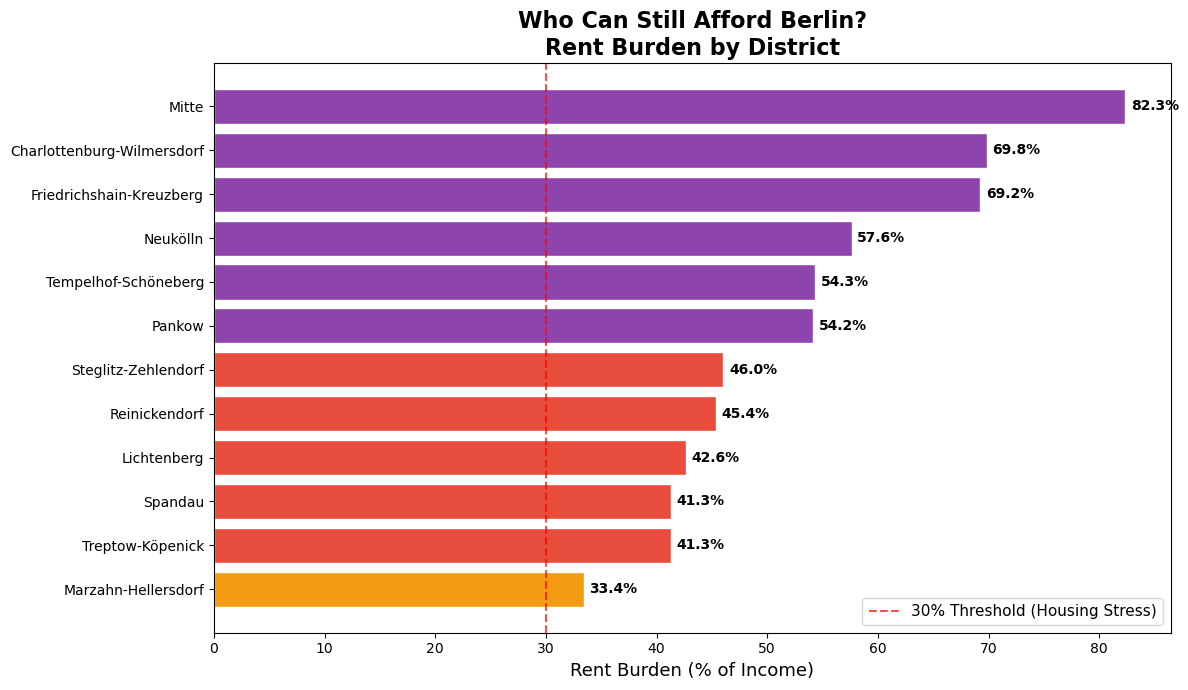

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))
sorted_master = master.sort_values('rent_burden_pct', ascending=True)
bar_colors = ['#2ecc71' if x < 25 else '#f39c12' if x < 35 else '#e74c3c' if x < 50 else '#8e44ad' 
              for x in sorted_master['rent_burden_pct']]

bars = ax.barh(sorted_master['district_name'], sorted_master['rent_burden_pct'], 
               color=bar_colors, edgecolor='white')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='30% Threshold (Housing Stress)')
ax.set_xlabel('Rent Burden (% of Income)', fontsize=13)
ax.set_title('Who Can Still Afford Berlin?\nRent Burden by District', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)

for bar, val in zip(bars, sorted_master['rent_burden_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_rent_burden.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Rent Distribution Across Districts


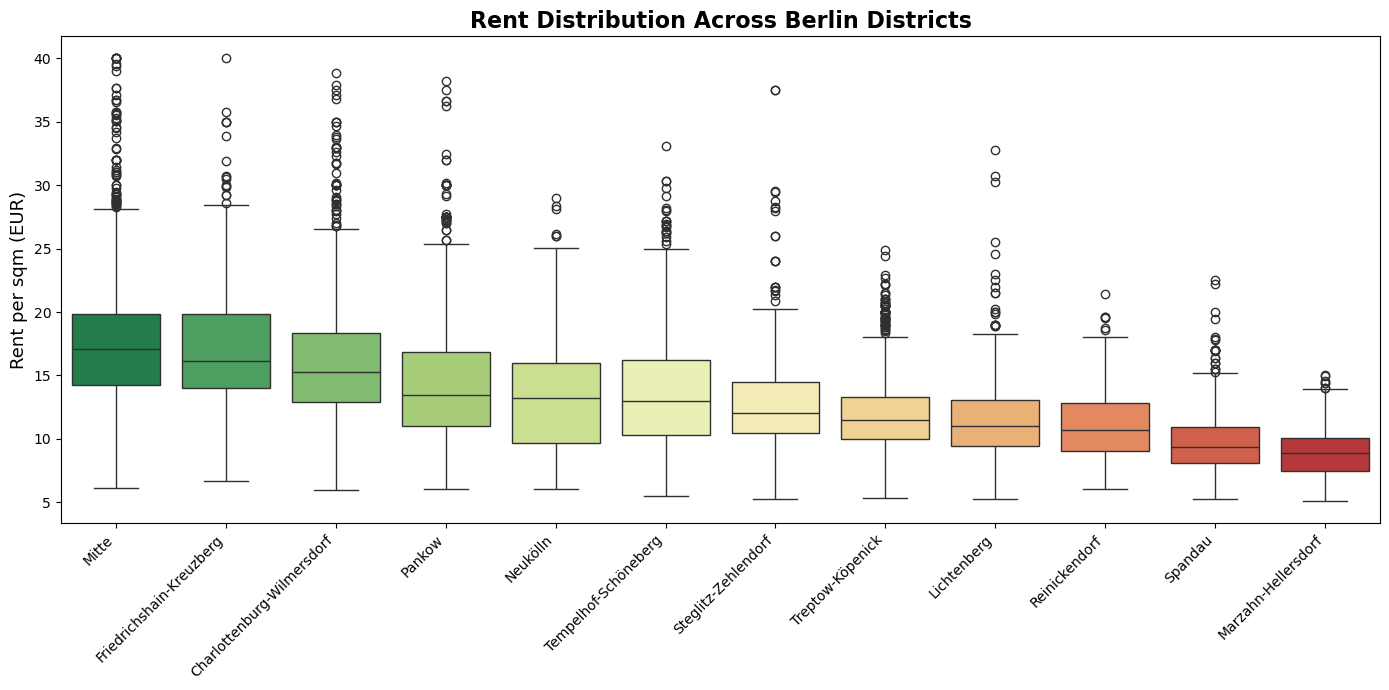

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
order = housing.groupby('bezirk')['rent_per_sqm'].median().sort_values(ascending=False).index
sns.boxplot(data=housing, x='bezirk', y='rent_per_sqm', order=order, palette='RdYlGn_r', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Rent per sqm (EUR)', fontsize=13)
ax.set_xlabel('')
ax.set_title('Rent Distribution Across Berlin Districts', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_rent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Social Status Index vs Rent (The Affordability Paradox)


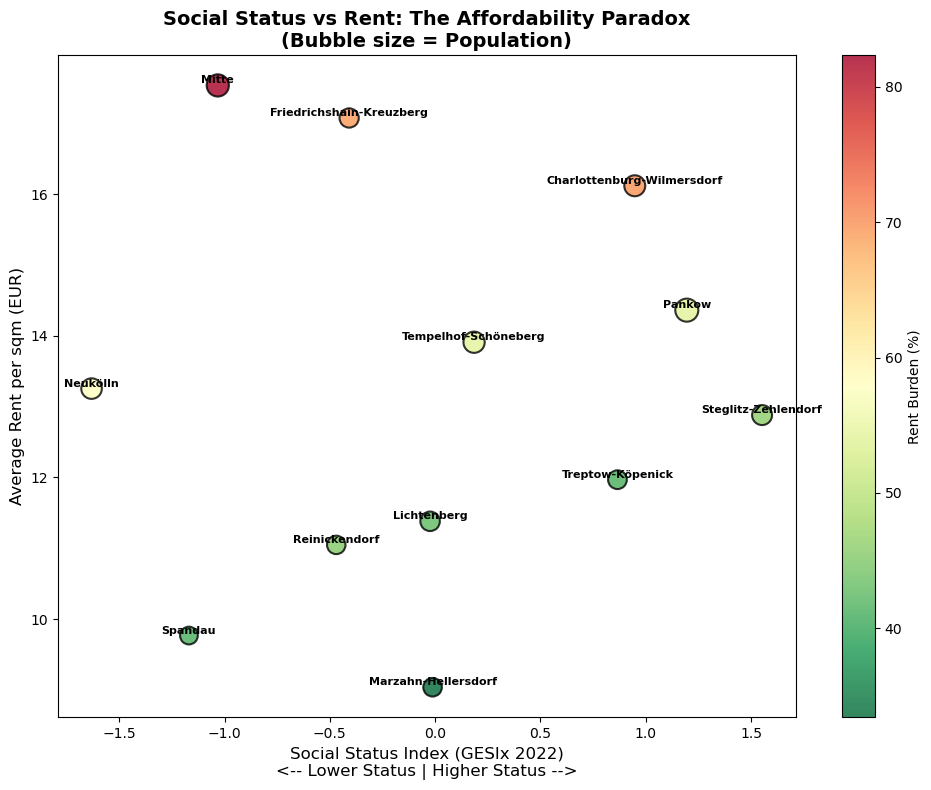

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(master['GESIx_2022'], master['avg_rent_sqm'], 
                     s=master['population']/1500, c=master['rent_burden_pct'], 
                     cmap='RdYlGn_r', edgecolors='black', alpha=0.8, linewidth=1.5)

for _, row in master.iterrows():
    ax.annotate(row['district_name'], (row['GESIx_2022'], row['avg_rent_sqm']),
                fontsize=8, ha='center', va='bottom', fontweight='bold')

plt.colorbar(scatter, label='Rent Burden (%)', ax=ax)
ax.set_xlabel('Social Status Index (GESIx 2022)\n<-- Lower Status | Higher Status -->', fontsize=12)
ax.set_ylabel('Average Rent per sqm (EUR)', fontsize=12)
ax.set_title('Social Status vs Rent: The Affordability Paradox\n(Bubble size = Population)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_social_vs_rent.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Income vs Rent Comparison


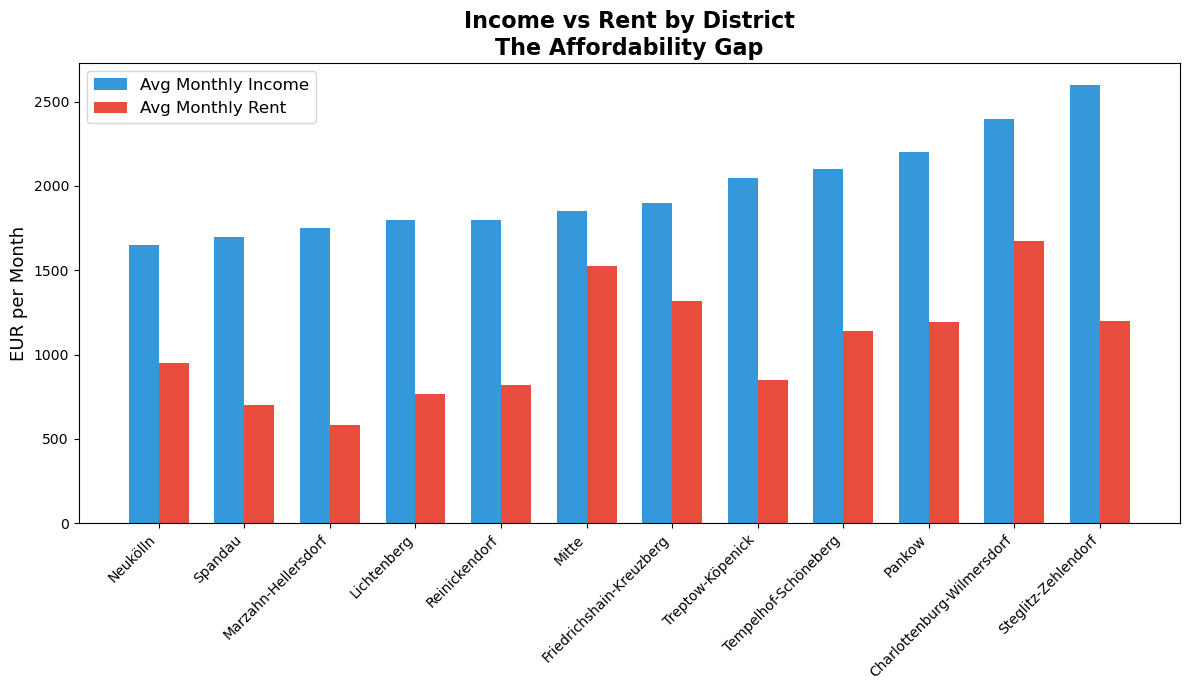

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))
sorted_m = master.sort_values('avg_monthly_income_eur')
x = range(len(sorted_m))
width = 0.35

ax.bar([i - width/2 for i in x], sorted_m['avg_monthly_income_eur'], width, 
       label='Avg Monthly Income', color='#3498db')
ax.bar([i + width/2 for i in x], sorted_m['avg_monthly_rent'], width, 
       label='Avg Monthly Rent', color='#e74c3c')

ax.set_xticks(list(x))
ax.set_xticklabels(sorted_m['district_name'], rotation=45, ha='right')
ax.set_ylabel('EUR per Month', fontsize=13)
ax.set_title('Income vs Rent by District\nThe Affordability Gap', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('fig4_income_vs_rent.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Correlation Matrix


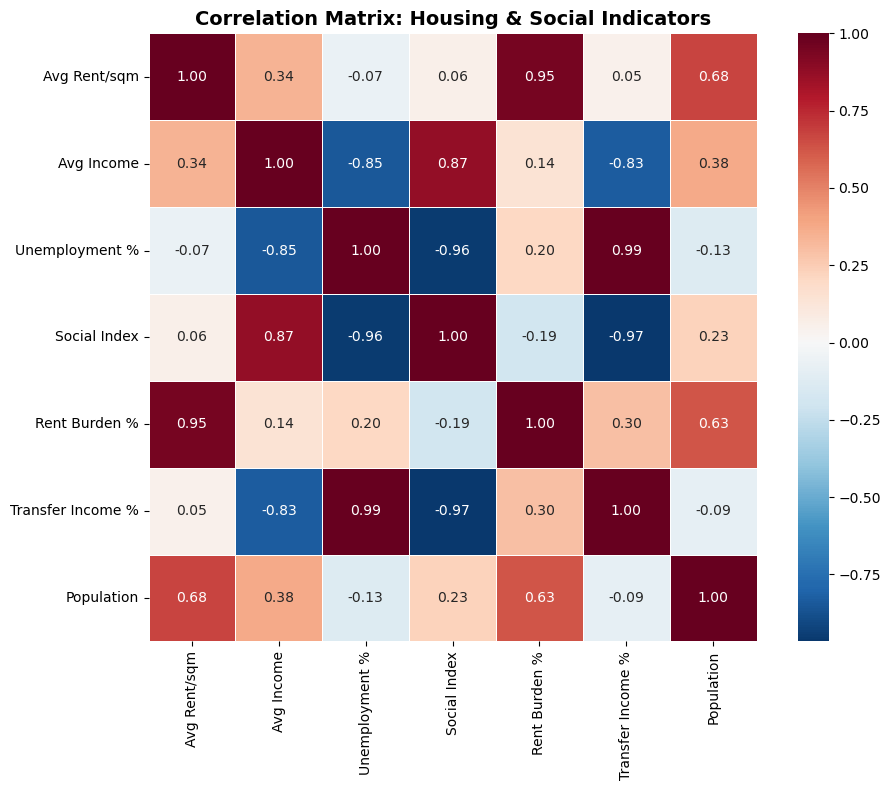

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['avg_rent_sqm', 'avg_monthly_income_eur', 'unemployment_rate_pct', 
             'GESIx_2022', 'rent_burden_pct', 'transfer_income_share_pct', 'population']
corr_labels = ['Avg Rent/sqm', 'Avg Income', 'Unemployment %', 
               'Social Index', 'Rent Burden %', 'Transfer Income %', 'Population']
corr = master[corr_cols].corr()
corr.index = corr_labels
corr.columns = corr_labels
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, 
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: Housing & Social Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Key Findings

### The Answer: Almost Nobody Can Comfortably Afford Berlin

1. **Every single district exceeds the 30% housing stress threshold.** Even the most affordable district (Marzahn-Hellersdorf at 33.4%) is above the internationally recognized limit.

2. **The most burdened districts are Mitte (82.3%), Charlottenburg-Wilmersdorf (69.8%), and Friedrichshain-Kreuzberg (69.2%)** — these central districts have both high rents and attract residents whose incomes don't match the cost.

3. **The "Affordability Paradox"**: Districts with lower social status indices (Neukolln, Mitte) have high rent burdens because low-income residents face rising rents from gentrification. Wealthier districts (Steglitz-Zehlendorf) have high rents but also higher incomes, resulting in lower relative burden.

4. **Strong negative correlation (-0.70) between Social Status Index and rent burden** — confirming that socially disadvantaged areas are disproportionately affected by housing costs.

5. **Unemployment and transfer income strongly correlate with rent burden** — districts with higher unemployment (Neukolln 14.1%, Mitte 12.8%) face the worst affordability crisis.


## 7. Export for Tableau


In [27]:
# Save master dataset for Tableau dashboard
master.to_csv('berlin_affordability_master.csv', index=False)
print("Saved: berlin_affordability_master.csv (district-level summary)")

# Save detailed housing with income for drill-down analysis
housing_detailed = housing.merge(income, left_on='bezirk', right_on='district_name', how='left')
housing_detailed['rent_burden_pct'] = (housing_detailed['baseRent'] / housing_detailed['avg_monthly_income_eur']) * 100
housing_detailed.to_csv('berlin_housing_detailed_tableau.csv', index=False)
print(f"Saved: berlin_housing_detailed_tableau.csv ({len(housing_detailed):,} rows)")

print("\nThese CSV files are ready to import into Tableau!")


Saved: berlin_affordability_master.csv (district-level summary)
Saved: berlin_housing_detailed_tableau.csv (10,309 rows)

These CSV files are ready to import into Tableau!


## 8. Tableau Dashboard Guide

Import the exported CSVs into Tableau and create:

1. **Choropleth Map** — Rent burden % by district (use `berlin_affordability_master.csv`)
2. **Bar Chart** — Rent burden ranking by district  
3. **Scatter Plot** — Social Status Index vs Average Rent (color by affordability class)
4. **Side-by-Side Bars** — Income vs Rent comparison
5. **Interactive Filters** — Allow filtering by district, room count, apartment type

### Recommended Dashboard Layout:
- Top row: Map (left) + Key metric cards (right)
- Middle row: Rent burden bar chart (full width)
- Bottom row: Scatter plot (left) + Income vs Rent (right)
- Filters panel on the right side
